<a href="https://colab.research.google.com/github/R12-l/2023-Java-creando-tu-primera-aplicacion/blob/aula-1/TC%20histograma%202D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.8 MB/s eta 0:00:00


In [ ]:
!pip install dicom2nifti

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 67.9 MB/s eta 0:00:00


In [ ]:
# Importar librerías específicas
import dicom2nifti
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt
import pydicom

In [ ]:
dicom_file = pydicom.dcmread('/content/drive/MyDrive/Colab Notebooks/ID_0000_AGE_0060_CONTRAST_1_CT.dcm')

In [ ]:
print(dicom_file)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 194
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.7777.9002.108821836759549281694712274169
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.31'
-------------------------------------------------
(0008,0000) Group Length                        UL: 430
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.7777.9002.1088218367595492

In [ ]:
dicom_file[0x0028, 0x0010]
# (0028,0010) Rows US: 512

(0028,0010) Rows                                US: 512

In [ ]:
dicom_file.Rows

512

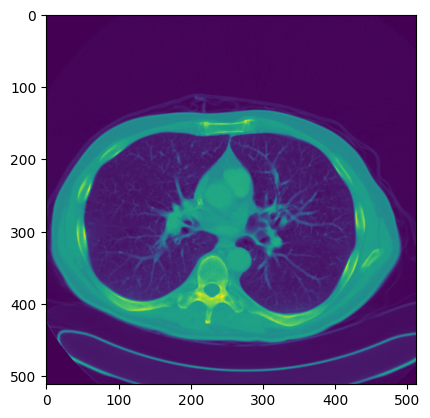

In [ ]:
ct = dicom_file.pixel_array # Extraer la matriz de píxeles de la imagen DICOM
plt.figure()
plt.imshow(ct)

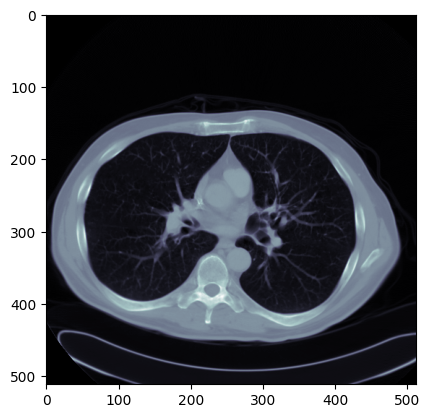

In [ ]:
plt.figure()
plt.imshow(ct, cmap = 'bone')

(0.0, 10000.0)

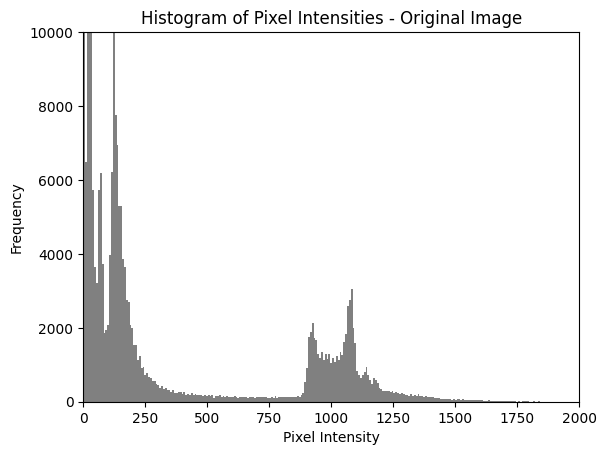

In [ ]:
# Histograma de la Imagen Original
plt.figure()
plt.hist(ct.ravel(), bins = 256, color = 'gray')
plt.title('Histogram of Pixel Intensities - Original Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.xlim(0, 2000)
plt.ylim(0, 10000)

In [ ]:
# Histograma en una imagen, es una representación gráfica que muestra la distribución de los niveles de intensidad de los píxeles.
# Cada nivel de intensidad (0 - 255 en una imagen de 8 bits) tiene una frecuencia asociada

# Imágenes de BAJO CONTRASTE
# Imágenes de ALTO CONTRASTE

# Ecualización de Histograma
  # Redistribuir los niveles de intensidad para que ocupen el rango completo de los valores posibles
    # Pasos
      # Calcular el histograma
      # Calcular la Función de Distribución Acumulativa (CDF) = representa la suma acumulada de frecuencias hasta cada nivel de intensidad
      # Mapeo de intensidades
      # Generar la imagen ecualizada

In [ ]:
# Ecualización del histograma
from skimage import exposure

In [ ]:
ct_equalized = exposure.equalize_hist(ct)

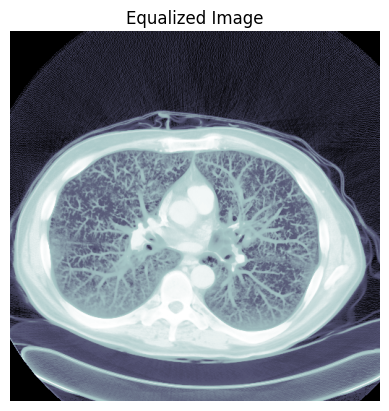

In [ ]:
plt.figure()
plt.imshow(ct_equalized, cmap = 'bone')
plt.title('Equalized Image')
plt.axis('off')
plt.show()

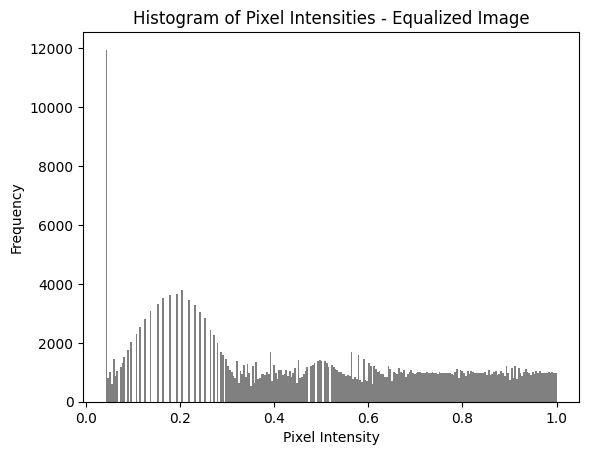

In [ ]:
# Histograma de la Imagen Ecualizada
plt.figure()
plt.hist(ct_equalized.ravel(), bins = 256, color = 'gray')
plt.title('Histogram of Pixel Intensities - Equalized Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Filtrado Espacial (Spatial Domain Filtering)
  # Convolución 2D con un Kernel de Detección de Bordes

from scipy.signal import convolve2d
import numpy as np
import cv2

In [ ]:
edge_kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])

In [ ]:
convoled_image = convolve2d(ct, edge_kernel, mode = 'same')

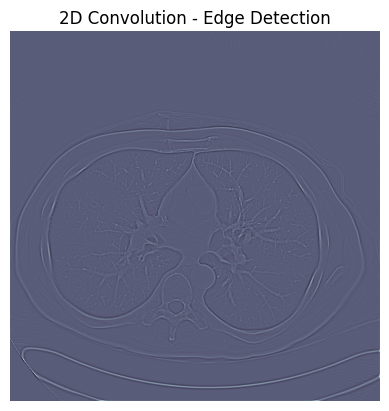

In [ ]:
plt.figure()
plt.imshow(convoled_image, cmap = 'bone')
plt.title('2D Convolution - Edge Detection')
plt.axis('off')
plt.show()

In [ ]:
convoled_image_cv = cv2.filter2D(ct, -1, edge_kernel)

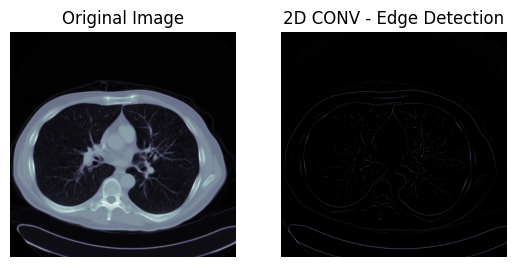

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(ct, cmap = 'bone')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(convoled_image_cv, cmap = 'bone')
plt.title('2D CONV - Edge Detection')
plt.axis('off')
plt.show()

In [ ]:
# Ajuste de kernel
edge_kernel_ajusted = np.array([[-2, -2, -2], [-2, 17, -2], [-2, -2, -2]])

In [ ]:
convoled_image_2 = convolve2d(ct, edge_kernel_ajusted, mode = 'same')

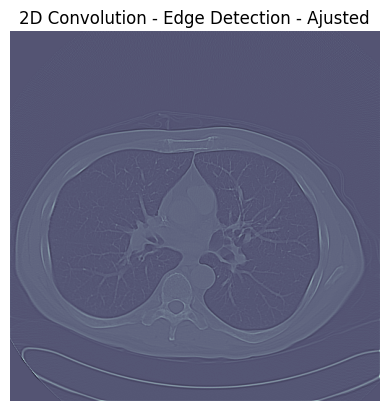

In [ ]:
plt.figure()
plt.imshow(convoled_image_2, cmap = 'bone')
plt.title('2D Convolution - Edge Detection - Ajusted')
plt.axis('off')
plt.show()

In [ ]:
convoled_image_cv_2 = cv2.filter2D(ct, -1, edge_kernel_ajusted)

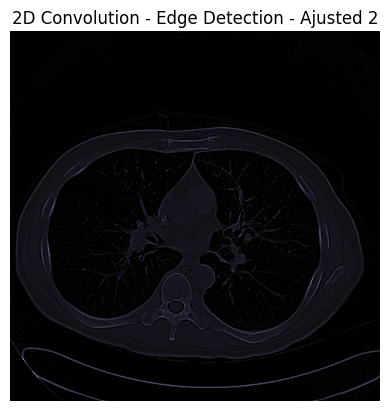

In [ ]:
plt.figure()
plt.imshow(convoled_image_cv_2, cmap = 'bone')
plt.title('2D Convolution - Edge Detection - Ajusted 2')
plt.axis('off')
plt.show()

In [ ]:
# Filtro de Media
mean_filtered_cv2 = cv2.blur(ct, (9,9))

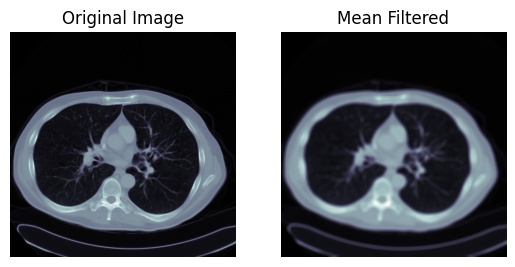

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(ct, cmap = 'bone')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mean_filtered_cv2, cmap = 'bone')
plt.title('Mean Filtered')
plt.axis('off')
plt.show()

In [ ]:
# Filtro de Mediana
median_filtered_cv2 = cv2.medianBlur(ct, 5)

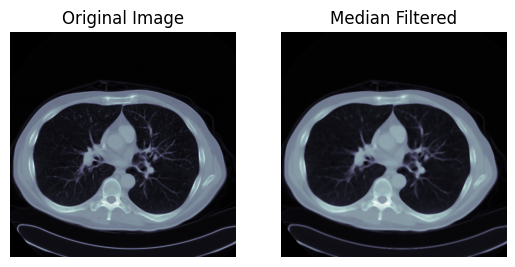

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(ct, cmap = 'bone')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(median_filtered_cv2, cmap = 'bone')
plt.title('Median Filtered')
plt.axis('off')
plt.show()

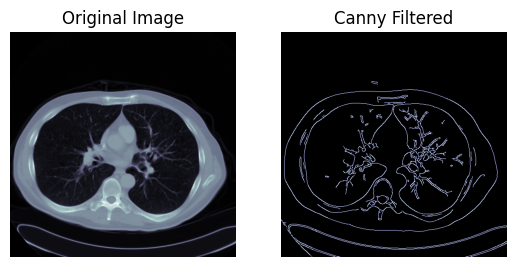

In [ ]:
# Convertir la imagen a uint8
ct_image_uint8 = (ct / ct.max() *255).astype(np.uint8)

# Aplicar filtro Canny
canny_filtered = cv2.Canny(ct_image_uint8, 60, 200)

plt.subplot(1, 2, 1)
plt.imshow(ct_image_uint8, cmap = 'bone')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canny_filtered, cmap = 'bone')
plt.title('Canny Filtered')
plt.axis('off')
plt.show()

In [ ]:
# Filtro de Sobel
sobelx = cv2.Sobel(ct, cv2.CV_64F, 1, 0, ksize = 7)
sobely = cv2.Sobel(ct, cv2.CV_64F, 0, 1, ksize = 7)
sobel_combined = cv2.magnitude(sobelx, sobely)

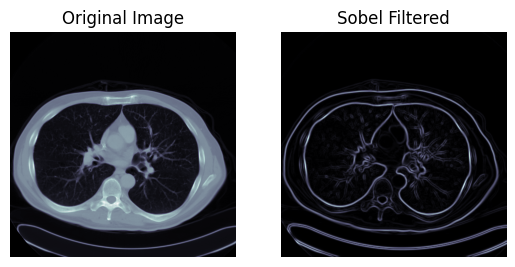

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(ct, cmap = 'bone')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_combined, cmap = 'bone')
plt.title('Sobel Filtered')
plt.axis('off')
plt.show()